# Hand-drawn Digit Image Generation with GAN


## Project Overview

### Purpose
Develop a Generative Adversarial Network (GAN) to generate realistic digit images, leveraging the competitive training of a generator and discriminator.

### Goals
- Train a GAN to generate synthetic digit images resembling the MNIST dataset.
- Evaluate generated images using visual and quantitative metrics.
- Showcase GANs' potential in generating realistic synthetic data.

### Significance
GANs have transformed AI by enabling realistic data generation, with applications in data augmentation, creative design, and beyond.

#### PyTorch Setup Instructions
This notebook was trained on **PyTorch version 2.6.0+cu126 with CUDA 12.6** as the platform. To ensure this works correctly on your system, please run the following commands in the kernel terminal where you are running this notebook:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
pip install jupyter matplotlib numpy
```

### Import Necessary Libraries

In [24]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

#### Check CUDA Availability

In [25]:
print(f"Pytorch Version: {torch.__version__}")
print(f"Cuda version: {torch.version.cuda}")
print(f"Is CUDA version availaible: {torch.cuda.is_available()}")

# Check CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Pytorch Version: 2.6.0+cu126
Cuda version: 12.6
Is CUDA version availaible: True
Using device: cuda


#### Hyperparameters

In [26]:

# Hyperparameters
batch_size = 128
latent_dim = 100
lr = 0.0004
epochs = 500
num_classes = 10 


### Dataset Description

#### Source
The MNIST dataset, a benchmark in machine learning, contains grayscale images of handwritten digits (0-9). It is publicly available via sources like the `torchvision` library.

#### Size
- **Training set**: 60,000 images  
- **Test set**: 10,000 images  
Each image is 28x28 pixels, grayscale.

#### Preprocessing
1. **Normalization**: Scaled pixel values to [0, 1] for better training convergence.  
2. **Reshaping**: Adjusted image dimensions to match GAN input requirements.  
3. **Data Loading**: Used `torch.utils.data.DataLoader` for efficient batch processing.



In [27]:

# Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True
)



## Model Architecture

### Overview
The Generative Adversarial Network (GAN) consists of two components:
1. **Generator**: Generates synthetic digit images from random noise.
2. **Discriminator**: Distinguishes between real and synthetic images.

These networks are trained simultaneously in a competitive setting: the generator aims to produce realistic images, while the discriminator learns to classify images as real or fake.

---
 
### Generator Architecture
The generator maps random noise vectors to realistic digit images using transposed convolutional layers.

- **Input**: Random noise vector (size 100).
- **Layers**:
  - Fully connected layer to reshape noise into a feature map.
  - Transposed convolutional layers with ReLU activations for upsampling.
  - Batch normalization layers for training stability.
  - Final transposed convolutional layer with Tanh activation to generate the output image.
- **Output**: 28x28 grayscale image.

---

### Discriminator Architecture
The discriminator is a convolutional neural network (CNN) that classifies images as real or fake.

- **Input**: 28x28 grayscale image.
- **Layers**:
  - Convolutional layers with LeakyReLU activations for feature extraction.
  - Dropout layers to prevent overfitting.
  - Fully connected layer to output a single probability value.
- **Output**: Scalar value representing the probability of the image being real.

---

### Key Components
- **LeakyReLU Activation**: Used in the discriminator for better gradient flow.
- **Tanh Activation**: Scales generator outputs to [-1, 1], matching normalized dataset values.
- **Batch Normalization**: Stabilizes training and improves convergence in the generator.

---



In [28]:
class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(784 + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_embedding = self.label_emb(labels)
        x = torch.cat([img_flat, label_embedding], dim=1)
        return self.model(x)

In [29]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat([z, label_embedding], dim=1)
        return self.model(x).view(-1, 1, 28, 28)



[Epoch 1/500] D_loss: 0.0310 G_loss: 34.1496
[Epoch 2/500] D_loss: 0.0467 G_loss: 25.0266
[Epoch 3/500] D_loss: 0.0037 G_loss: 46.2293
[Epoch 4/500] D_loss: 0.0341 G_loss: 42.3656
[Epoch 5/500] D_loss: 0.0378 G_loss: 53.9091
[Epoch 6/500] D_loss: 0.0441 G_loss: 19.3313
[Epoch 7/500] D_loss: 0.0239 G_loss: 25.3164
[Epoch 8/500] D_loss: 0.3765 G_loss: 16.0222
[Epoch 9/500] D_loss: 0.0938 G_loss: 20.4877
[Epoch 10/500] D_loss: 0.0522 G_loss: 25.0500
[Epoch 11/500] D_loss: 0.6458 G_loss: 13.2130
[Epoch 12/500] D_loss: 0.7869 G_loss: 12.1026
[Epoch 13/500] D_loss: 1.1039 G_loss: 10.6921
[Epoch 14/500] D_loss: 0.7832 G_loss: 9.2942
[Epoch 15/500] D_loss: 0.8934 G_loss: 19.9654
[Epoch 16/500] D_loss: 1.0502 G_loss: 7.8686
[Epoch 17/500] D_loss: 0.8700 G_loss: 12.0778
[Epoch 18/500] D_loss: 1.2517 G_loss: 15.1250
[Epoch 19/500] D_loss: 0.7182 G_loss: 2.7867
[Epoch 20/500] D_loss: 0.7106 G_loss: 2.3182
[Epoch 21/500] D_loss: 0.7481 G_loss: 2.9570
[Epoch 22/500] D_loss: 0.8311 G_loss: 2.3441
[Ep

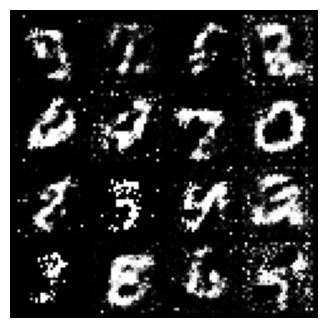

[Epoch 51/500] D_loss: 1.0809 G_loss: 1.6924
[Epoch 52/500] D_loss: 0.9214 G_loss: 1.8701
[Epoch 53/500] D_loss: 0.9643 G_loss: 1.5290
[Epoch 54/500] D_loss: 1.0025 G_loss: 1.5092
[Epoch 55/500] D_loss: 0.8990 G_loss: 1.8004
[Epoch 56/500] D_loss: 0.9555 G_loss: 1.5768
[Epoch 57/500] D_loss: 1.0783 G_loss: 1.7096
[Epoch 58/500] D_loss: 1.0274 G_loss: 1.5724
[Epoch 59/500] D_loss: 1.0121 G_loss: 1.4406
[Epoch 60/500] D_loss: 0.9994 G_loss: 1.7747
[Epoch 61/500] D_loss: 0.8929 G_loss: 1.7640
[Epoch 62/500] D_loss: 0.9125 G_loss: 1.5881
[Epoch 63/500] D_loss: 1.1609 G_loss: 1.7453
[Epoch 64/500] D_loss: 1.0352 G_loss: 1.6864
[Epoch 65/500] D_loss: 1.0405 G_loss: 1.4566
[Epoch 66/500] D_loss: 1.1052 G_loss: 1.3854
[Epoch 67/500] D_loss: 1.0280 G_loss: 1.1463
[Epoch 68/500] D_loss: 0.9458 G_loss: 1.7354
[Epoch 69/500] D_loss: 1.1892 G_loss: 1.1778
[Epoch 70/500] D_loss: 1.2293 G_loss: 1.3115
[Epoch 71/500] D_loss: 1.1165 G_loss: 1.1612
[Epoch 72/500] D_loss: 1.0488 G_loss: 1.2523
[Epoch 73/

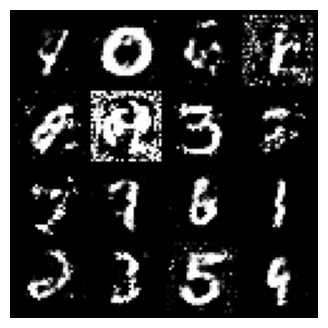

[Epoch 101/500] D_loss: 1.2034 G_loss: 1.0878
[Epoch 102/500] D_loss: 1.2279 G_loss: 0.9566
[Epoch 103/500] D_loss: 1.3464 G_loss: 0.9710
[Epoch 104/500] D_loss: 1.1592 G_loss: 0.9250
[Epoch 105/500] D_loss: 1.1046 G_loss: 1.2089
[Epoch 106/500] D_loss: 1.1639 G_loss: 1.0226
[Epoch 107/500] D_loss: 1.2396 G_loss: 0.8580
[Epoch 108/500] D_loss: 1.2793 G_loss: 0.9411
[Epoch 109/500] D_loss: 1.1889 G_loss: 0.9438
[Epoch 110/500] D_loss: 1.1560 G_loss: 1.1274
[Epoch 111/500] D_loss: 1.3257 G_loss: 0.9469
[Epoch 112/500] D_loss: 1.1445 G_loss: 1.1355
[Epoch 113/500] D_loss: 1.2327 G_loss: 1.1211
[Epoch 114/500] D_loss: 1.3304 G_loss: 1.1101
[Epoch 115/500] D_loss: 1.2563 G_loss: 1.0460
[Epoch 116/500] D_loss: 1.2745 G_loss: 1.0788
[Epoch 117/500] D_loss: 1.0157 G_loss: 1.1943
[Epoch 118/500] D_loss: 1.1172 G_loss: 1.0679
[Epoch 119/500] D_loss: 1.2467 G_loss: 0.9568
[Epoch 120/500] D_loss: 1.2388 G_loss: 1.1710
[Epoch 121/500] D_loss: 1.2610 G_loss: 0.9675
[Epoch 122/500] D_loss: 1.2693 G_l

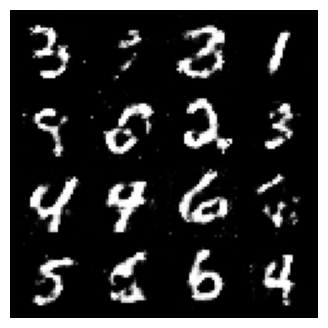

[Epoch 151/500] D_loss: 1.2263 G_loss: 0.9600
[Epoch 152/500] D_loss: 1.3022 G_loss: 0.7596
[Epoch 153/500] D_loss: 1.2987 G_loss: 1.2348
[Epoch 154/500] D_loss: 1.2841 G_loss: 0.9234
[Epoch 155/500] D_loss: 1.2813 G_loss: 0.9168
[Epoch 156/500] D_loss: 1.3556 G_loss: 1.1936
[Epoch 157/500] D_loss: 1.2717 G_loss: 0.9522
[Epoch 158/500] D_loss: 1.3793 G_loss: 0.8310
[Epoch 159/500] D_loss: 1.2594 G_loss: 0.8561
[Epoch 160/500] D_loss: 1.2696 G_loss: 0.9498
[Epoch 161/500] D_loss: 1.4269 G_loss: 0.9954
[Epoch 162/500] D_loss: 1.4094 G_loss: 0.9216
[Epoch 163/500] D_loss: 1.3078 G_loss: 0.8829
[Epoch 164/500] D_loss: 1.2832 G_loss: 1.0475
[Epoch 165/500] D_loss: 1.1968 G_loss: 1.0789
[Epoch 166/500] D_loss: 1.1826 G_loss: 1.1494
[Epoch 167/500] D_loss: 1.3543 G_loss: 0.9358
[Epoch 168/500] D_loss: 1.2988 G_loss: 0.9081
[Epoch 169/500] D_loss: 1.3250 G_loss: 0.9068
[Epoch 170/500] D_loss: 1.3425 G_loss: 0.7918
[Epoch 171/500] D_loss: 1.2430 G_loss: 0.9112
[Epoch 172/500] D_loss: 1.2686 G_l

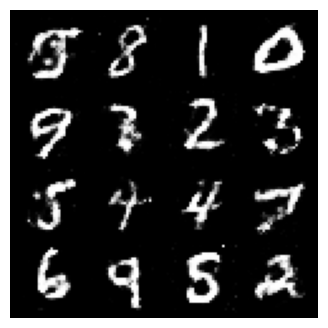

[Epoch 201/500] D_loss: 1.2988 G_loss: 0.7589
[Epoch 202/500] D_loss: 1.3226 G_loss: 0.8558
[Epoch 203/500] D_loss: 1.3327 G_loss: 0.8719
[Epoch 204/500] D_loss: 1.2380 G_loss: 0.7893
[Epoch 205/500] D_loss: 1.2001 G_loss: 0.8673
[Epoch 206/500] D_loss: 1.3480 G_loss: 0.6874
[Epoch 207/500] D_loss: 1.1488 G_loss: 0.9448
[Epoch 208/500] D_loss: 1.2841 G_loss: 0.8789
[Epoch 209/500] D_loss: 1.3824 G_loss: 0.9508
[Epoch 210/500] D_loss: 1.4171 G_loss: 0.8611
[Epoch 211/500] D_loss: 1.3211 G_loss: 0.8973
[Epoch 212/500] D_loss: 1.3509 G_loss: 0.8272
[Epoch 213/500] D_loss: 1.3187 G_loss: 0.8536
[Epoch 214/500] D_loss: 1.3872 G_loss: 0.8011
[Epoch 215/500] D_loss: 1.3137 G_loss: 0.7796
[Epoch 216/500] D_loss: 1.4179 G_loss: 0.7420
[Epoch 217/500] D_loss: 1.2909 G_loss: 0.8328
[Epoch 218/500] D_loss: 1.3110 G_loss: 1.0303
[Epoch 219/500] D_loss: 1.3326 G_loss: 0.8032
[Epoch 220/500] D_loss: 1.3703 G_loss: 0.8203
[Epoch 221/500] D_loss: 1.2790 G_loss: 0.9046
[Epoch 222/500] D_loss: 1.2932 G_l

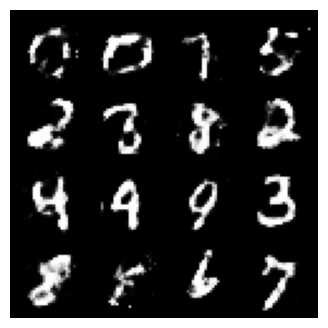

[Epoch 251/500] D_loss: 1.3621 G_loss: 1.0335
[Epoch 252/500] D_loss: 1.3233 G_loss: 0.9160
[Epoch 253/500] D_loss: 1.3523 G_loss: 0.9706
[Epoch 254/500] D_loss: 1.3754 G_loss: 0.7778
[Epoch 255/500] D_loss: 1.2184 G_loss: 0.9121
[Epoch 256/500] D_loss: 1.3846 G_loss: 0.7654
[Epoch 257/500] D_loss: 1.4490 G_loss: 0.9282
[Epoch 258/500] D_loss: 1.4026 G_loss: 0.8496
[Epoch 259/500] D_loss: 1.3884 G_loss: 0.9794
[Epoch 260/500] D_loss: 1.4771 G_loss: 0.8280
[Epoch 261/500] D_loss: 1.4026 G_loss: 0.7633
[Epoch 262/500] D_loss: 1.3227 G_loss: 0.8206
[Epoch 263/500] D_loss: 1.1793 G_loss: 0.8646
[Epoch 264/500] D_loss: 1.2625 G_loss: 1.0013
[Epoch 265/500] D_loss: 1.2424 G_loss: 0.9422
[Epoch 266/500] D_loss: 1.3614 G_loss: 0.8367
[Epoch 267/500] D_loss: 1.2903 G_loss: 0.8318
[Epoch 268/500] D_loss: 1.3904 G_loss: 0.8419
[Epoch 269/500] D_loss: 1.1959 G_loss: 0.9249
[Epoch 270/500] D_loss: 1.2949 G_loss: 0.9654
[Epoch 271/500] D_loss: 1.2839 G_loss: 0.8837
[Epoch 272/500] D_loss: 1.2807 G_l

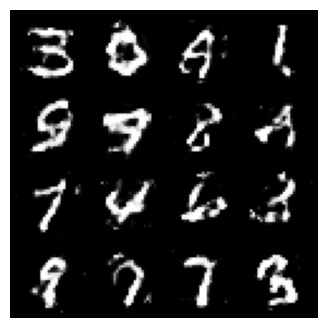

[Epoch 301/500] D_loss: 1.3686 G_loss: 0.7925
[Epoch 302/500] D_loss: 1.3291 G_loss: 0.7798
[Epoch 303/500] D_loss: 1.4202 G_loss: 0.7479
[Epoch 304/500] D_loss: 1.2697 G_loss: 0.8779
[Epoch 305/500] D_loss: 1.2516 G_loss: 0.8942
[Epoch 306/500] D_loss: 1.2744 G_loss: 0.8837
[Epoch 307/500] D_loss: 1.3298 G_loss: 0.7391
[Epoch 308/500] D_loss: 1.2969 G_loss: 0.7196
[Epoch 309/500] D_loss: 1.2804 G_loss: 0.7967
[Epoch 310/500] D_loss: 1.3652 G_loss: 0.7540
[Epoch 311/500] D_loss: 1.2491 G_loss: 0.9440
[Epoch 312/500] D_loss: 1.3037 G_loss: 0.7568
[Epoch 313/500] D_loss: 1.5366 G_loss: 0.7834
[Epoch 314/500] D_loss: 1.3202 G_loss: 0.8849
[Epoch 315/500] D_loss: 1.2602 G_loss: 1.0659
[Epoch 316/500] D_loss: 1.2250 G_loss: 0.7957
[Epoch 317/500] D_loss: 1.2635 G_loss: 0.8074
[Epoch 318/500] D_loss: 1.3062 G_loss: 0.9568
[Epoch 319/500] D_loss: 1.6105 G_loss: 0.7105
[Epoch 320/500] D_loss: 1.2515 G_loss: 0.9290
[Epoch 321/500] D_loss: 1.3306 G_loss: 0.8586
[Epoch 322/500] D_loss: 1.3688 G_l

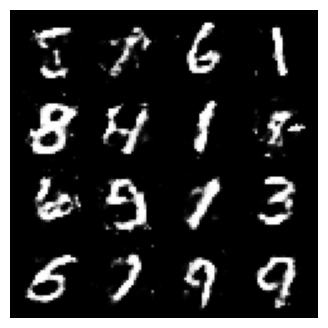

[Epoch 351/500] D_loss: 1.2704 G_loss: 0.8802
[Epoch 352/500] D_loss: 1.1909 G_loss: 0.9323
[Epoch 353/500] D_loss: 1.2491 G_loss: 0.9700
[Epoch 354/500] D_loss: 1.3601 G_loss: 0.7924
[Epoch 355/500] D_loss: 1.3861 G_loss: 0.7565
[Epoch 356/500] D_loss: 1.3345 G_loss: 0.7940
[Epoch 357/500] D_loss: 1.3895 G_loss: 0.9535
[Epoch 358/500] D_loss: 1.3924 G_loss: 0.7642
[Epoch 359/500] D_loss: 1.3231 G_loss: 0.7542
[Epoch 360/500] D_loss: 1.3248 G_loss: 0.8582
[Epoch 361/500] D_loss: 1.2182 G_loss: 0.8511
[Epoch 362/500] D_loss: 1.2825 G_loss: 0.7374
[Epoch 363/500] D_loss: 1.3597 G_loss: 0.7937
[Epoch 364/500] D_loss: 1.2982 G_loss: 0.9191
[Epoch 365/500] D_loss: 1.3154 G_loss: 0.8348
[Epoch 366/500] D_loss: 1.2661 G_loss: 0.7476
[Epoch 367/500] D_loss: 1.4202 G_loss: 0.7127
[Epoch 368/500] D_loss: 1.3060 G_loss: 0.7926
[Epoch 369/500] D_loss: 1.2718 G_loss: 0.8794
[Epoch 370/500] D_loss: 1.2792 G_loss: 0.8235
[Epoch 371/500] D_loss: 1.3440 G_loss: 0.7712
[Epoch 372/500] D_loss: 1.3583 G_l

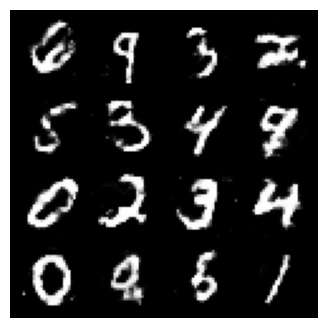

[Epoch 401/500] D_loss: 1.3367 G_loss: 0.7625
[Epoch 402/500] D_loss: 1.2649 G_loss: 0.7898
[Epoch 403/500] D_loss: 1.2628 G_loss: 0.9017
[Epoch 404/500] D_loss: 1.2461 G_loss: 0.8359
[Epoch 405/500] D_loss: 1.3470 G_loss: 0.7815
[Epoch 406/500] D_loss: 1.1988 G_loss: 0.9716
[Epoch 407/500] D_loss: 1.3451 G_loss: 0.8044
[Epoch 408/500] D_loss: 1.2849 G_loss: 0.9797
[Epoch 409/500] D_loss: 1.3114 G_loss: 0.8988
[Epoch 410/500] D_loss: 1.3286 G_loss: 0.8194
[Epoch 411/500] D_loss: 1.3629 G_loss: 0.8388
[Epoch 412/500] D_loss: 1.3019 G_loss: 0.9037
[Epoch 413/500] D_loss: 1.4566 G_loss: 0.7789
[Epoch 414/500] D_loss: 1.3454 G_loss: 0.8804
[Epoch 415/500] D_loss: 1.1906 G_loss: 0.8931
[Epoch 416/500] D_loss: 1.3569 G_loss: 0.8305
[Epoch 417/500] D_loss: 1.3511 G_loss: 0.9000
[Epoch 418/500] D_loss: 1.3205 G_loss: 0.8945
[Epoch 419/500] D_loss: 1.4454 G_loss: 0.8326
[Epoch 420/500] D_loss: 1.4533 G_loss: 0.7364
[Epoch 421/500] D_loss: 1.3387 G_loss: 0.9022
[Epoch 422/500] D_loss: 1.3129 G_l

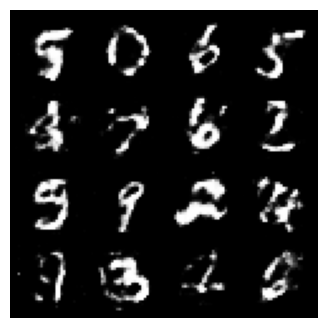

[Epoch 451/500] D_loss: 1.2000 G_loss: 1.2154
[Epoch 452/500] D_loss: 1.3780 G_loss: 0.8069
[Epoch 453/500] D_loss: 1.3737 G_loss: 0.8008
[Epoch 454/500] D_loss: 1.2009 G_loss: 0.8465
[Epoch 455/500] D_loss: 1.2971 G_loss: 0.7797
[Epoch 456/500] D_loss: 1.5538 G_loss: 0.7620
[Epoch 457/500] D_loss: 1.2440 G_loss: 0.9098
[Epoch 458/500] D_loss: 1.3787 G_loss: 0.8348
[Epoch 459/500] D_loss: 1.3422 G_loss: 0.8474
[Epoch 460/500] D_loss: 1.3759 G_loss: 0.7566
[Epoch 461/500] D_loss: 1.3470 G_loss: 0.7798
[Epoch 462/500] D_loss: 1.4043 G_loss: 0.8357
[Epoch 463/500] D_loss: 1.4685 G_loss: 0.7912
[Epoch 464/500] D_loss: 1.3789 G_loss: 0.7662
[Epoch 465/500] D_loss: 1.3155 G_loss: 0.8978
[Epoch 466/500] D_loss: 1.3469 G_loss: 0.8005
[Epoch 467/500] D_loss: 1.2908 G_loss: 0.8112
[Epoch 468/500] D_loss: 1.3039 G_loss: 0.8131
[Epoch 469/500] D_loss: 1.2557 G_loss: 0.9536
[Epoch 470/500] D_loss: 1.2767 G_loss: 0.8439
[Epoch 471/500] D_loss: 1.3040 G_loss: 0.8007
[Epoch 472/500] D_loss: 1.3263 G_l

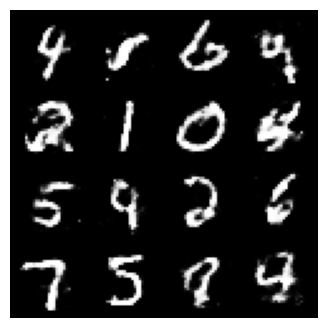

In [30]:


# Initialize models
generator = ConditionalGenerator(latent_dim, num_classes).to(device)
discriminator = ConditionalDiscriminator(num_classes).to(device)

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

# Loss function
criterion = nn.BCELoss()  

# Training loop
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(train_loader):
        real_imgs = imgs.to(device)
        labels = labels.to(device)  # Get actual digit labels
        
        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        
        # Real images with real labels
        real_output = discriminator(real_imgs, labels)  # Pass labels here
        d_loss_real = criterion(real_output, torch.ones_like(real_output))
        
        # Fake images with same labels
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z, labels)
        fake_output = discriminator(fake_imgs.detach(), labels)  # Pass labels here
        d_loss_fake = criterion(fake_output, torch.zeros_like(fake_output))
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # -----------------
        #  Train Generator
        # -----------------
        optimizer_G.zero_grad()
        
        # Generate fake images with same labels
        gen_output = discriminator(fake_imgs, labels)  # Pass labels here
        g_loss = criterion(gen_output, torch.ones_like(gen_output))
        
        g_loss.backward()
        optimizer_G.step()
        
    # Print progress
    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")
    
    # During training visualization
    if (epoch+1) % 50 == 0:
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim).to(device)
            test_labels = torch.randint(0, 10, (16,)).to(device)  # Random labels 0-9
            generated = generator(test_z, test_labels).cpu()  # Add labels here
            
            plt.figure(figsize=(4,4))
            plt.imshow(np.transpose(make_grid(generated, nrow=4, padding=2, normalize=True),(1,2,0)))
            plt.axis('off')
            plt.show()

# Save models
torch.save(generator.state_dict(), 'mnist_digit_generator.pth')
torch.save(discriminator.state_dict(), 'mnist_digit_discriminator.pth')

This section is option just to save the model for the GAN API interface if you intend to use it.

In [31]:
os.makedirs('gan-api/models', exist_ok=True)

torch.save(generator.state_dict(), 'gan-api/models/mnist_digit_generator.pth')
torch.save(discriminator.state_dict(), 'gan-api/models/mnist_digit_discriminator.pth')
print('Digits Models saved successfully in gan-api/models directory')

Digits Models saved successfully in gan-api/models directory


## Evaluation Metrics

### Overview
The performance of the GAN model is evaluated using a combination of qualitative and quantitative metrics.

#### 1. Inception Score (IS)
Evaluates the quality and diversity of generated images using a pre-trained classifier.

#### 2. Frechet Inception Distance (FID)
Compares the distribution of real and generated images in the feature space of a pre-trained network.

#### 3. Visual Inspection
Manually examining the generated images to assess their quality and diversity.

Discriminator Accuracy on Real: 0.6406
Discriminator Accuracy on Fake: 0.5180
Total Discriminator Accuracy: 0.5793


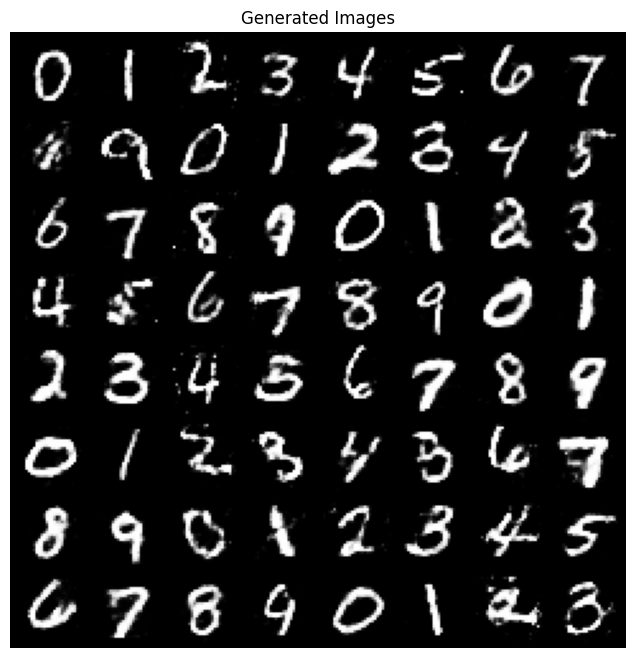

In [32]:
def show_images(images, title="Generated Images"):
    plt.figure(figsize=(8,8))
    plt.title(title)
    plt.axis('off')
    grid = make_grid(images.clamp(-1,1), nrow=8, padding=2, normalize=True)
    plt.imshow(np.transpose(grid.cpu().numpy(), (1,2,0)))
    plt.show()

# Updated evaluation function for conditional GAN
def evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels, n_samples=1000):
    generator.eval()
    discriminator.eval()
    with torch.no_grad():
        # Generate fake images with random labels
        z = torch.randn(n_samples, latent_dim).to(device)
        fake_labels = torch.randint(0, 10, (n_samples,)).to(device)
        fake_images = generator(z, fake_labels)
        
        # Get real images with their actual labels
        real_labels = real_labels[:n_samples].to(device)
        
        # Calculate discriminator outputs WITH LABELS
        real_output = discriminator(real_images, real_labels)
        fake_output = discriminator(fake_images, fake_labels)
        
        # Calculate discriminator accuracy
        real_acc = (real_output >= 0.5).float().mean()
        fake_acc = (fake_output < 0.5).float().mean()
        total_acc = (real_acc + fake_acc) / 2
        
        # Generate specific digits for visualization
        test_z = torch.randn(64, latent_dim).to(device)
        test_labels = torch.LongTensor([i % 10 for i in range(64)]).to(device)  # Digits 0-9 repeated
        generated = generator(test_z, test_labels).cpu()
        
    print(f"Discriminator Accuracy on Real: {real_acc.item():.4f}")
    print(f"Discriminator Accuracy on Fake: {fake_acc.item():.4f}")
    print(f"Total Discriminator Accuracy: {total_acc.item():.4f}")
    
    
    show_images(generated)

# Load real images WITH LABELS for evaluation
real_images, real_labels = next(iter(train_loader))
real_images = real_images[:1000].to(device)
real_labels = real_labels[:1000]  # Keep corresponding labels

# Run evaluation
evaluate_gan(generator, discriminator, latent_dim, real_images, real_labels)

### Results and Visualizations


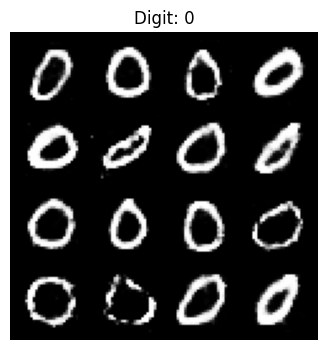

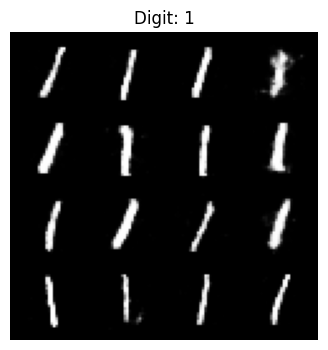

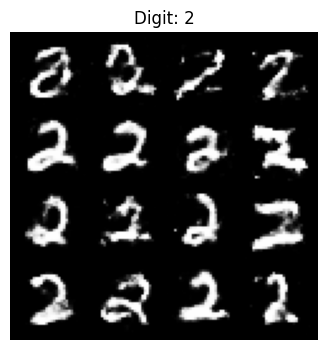

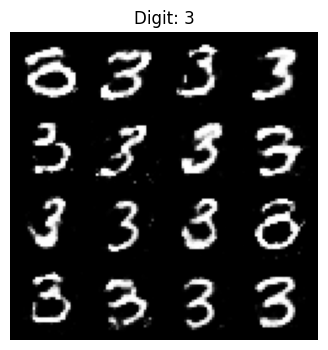

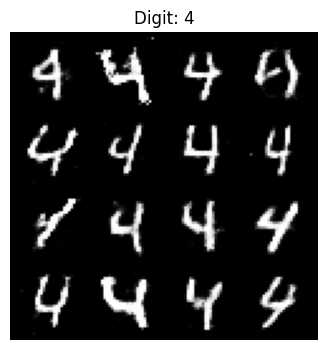

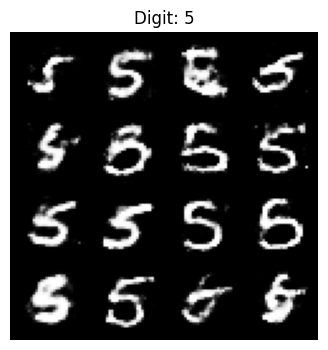

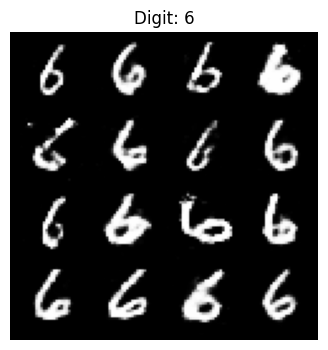

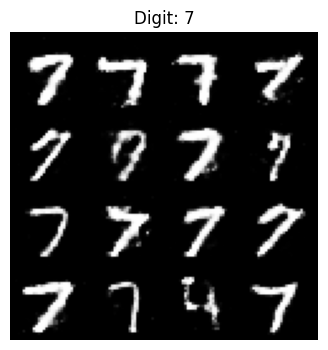

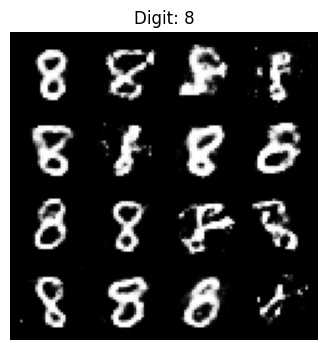

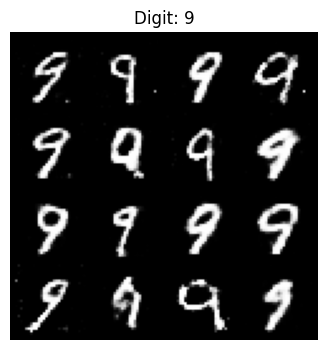

In [34]:
def generate_specific_digit(digit: int, num_samples: int = 16):
    generator.eval()
    with torch.no_grad():
        # Create labels tensor for desired digit
        labels = torch.full((num_samples,), digit, dtype=torch.long).to(device)
        
        z = torch.randn(num_samples, latent_dim).to(device)
        generated = generator(z, labels).cpu()  # Pass both z and labels
        
        plt.figure(figsize=(4,4))
        plt.imshow(np.transpose(make_grid(generated, nrow=4, padding=2, normalize=True), (1,2,0)))
        plt.title(f"Digit: {digit}")
        plt.axis('off')
        plt.show()

# Example: Generate 16 samples of digit 
for i in range(0,10):
    generate_specific_digit(i)

## Conclusion and Future Work

### Summary of Findings
This project successfully demonstrated the ability of GANs to generate realistic digit images resembling the MNIST dataset.

### Challenges Faced
- **Mode Collapse**: Limited variations from the generator.
- **Training Instability**: Balancing the generator and discriminator.
- **Computational Resources**: Intensive training requiring GPU usage.

### Closing Remarks
This project highlights GANs' potential in generating realistic synthetic data and opens avenues for further research and applications.